In [2]:
import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import datasets 

In [3]:
(X,y) = datasets.load_wine(return_X_y=True,as_frame=True)


In [4]:
print('Dhape of X:',X.shape)

Dhape of X: (178, 13)


In [5]:
X.head(3)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


In [6]:
y.shape

(178,)

In [7]:
y.groupby(y).count()

target
0    59
1    71
2    48
Name: target, dtype: int64

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
tree_instance = DecisionTreeClassifier(max_depth=2)

In [10]:
X.sample(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
166,13.45,3.70,2.60,23.0,111.0,1.7,0.92,0.43,1.46,10.68,0.85,1.56,695.0
54,13.74,1.67,2.25,16.4,118.0,2.6,2.90,0.21,1.62,5.85,0.92,3.20,1060.0


In [11]:
y.sample(3)

103    1
105    1
19     0
Name: target, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,y,random_state=22)

In [15]:
tree_instance.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
tree_instance.tree_.node_count

7

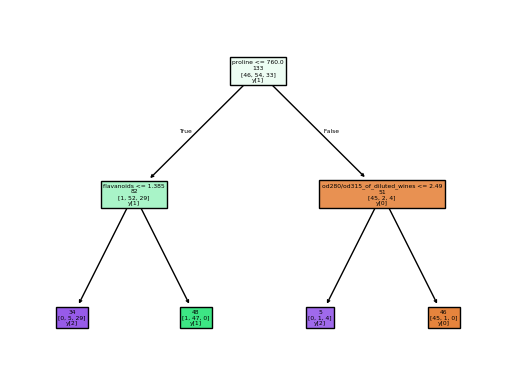

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
plot_tree(tree_instance,feature_names=X_train.columns,filled=True,class_names=True,label='none',impurity=False)
plt.show()

In [22]:
ypred=tree_instance.predict(X_test)
ypred

array([2, 2, 1, 2, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 2, 2, 0, 1,
       2, 1, 2, 2, 0, 2, 2, 2, 1, 0, 2, 1, 0, 2, 1, 0, 2, 1, 2, 1, 0, 1,
       2])

In [25]:
print(X_test.iloc[0:2,[6,9]])
print('Etiquetas: ', ypred[0:2])

     flavanoids  color_intensity
77         1.32             2.65
142        0.52             4.35
Etiquetas:  [2 2]


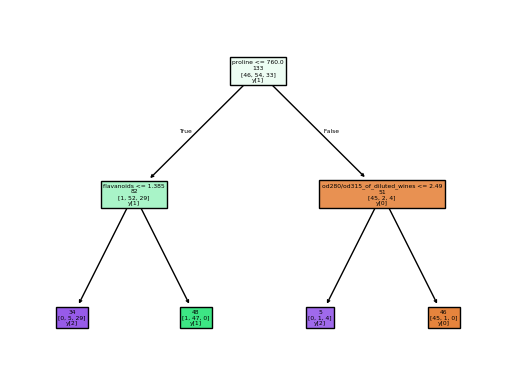

In [26]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
plot_tree(tree_instance,feature_names=X_train.columns,filled=True,class_names=True,label='none',impurity=False)
plt.show()

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,ypred)

0.7777777777777778